# Análise Exploratória - Diabetes 130-US Hospitals

Exploração inicial do dataset antes das etapas de pré-processamento.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import relatorio_dataset

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

Matplotlib is building the font cache; this may take a moment.


## 1. Carregando Dataset Original

In [4]:
# Baixar dataset automaticamente
from ucimlrepo import fetch_ucirepo

print("Baixando dataset UCI Diabetes 130-US Hospitals...")
dataset = fetch_ucirepo(id=296)
X = dataset.data.features
y = dataset.data.targets
df = pd.concat([X, y], axis=1)

print(f"✓ Dataset carregado: {df.shape}")
relatorio_dataset(df, "Dataset Original (UCI)")

Baixando dataset UCI Diabetes 130-US Hospitals...
✓ Dataset carregado: (101766, 48)

Dataset Original (UCI)
Shape: (101766, 48)
Colunas: ['race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Missing values (%):
weight               96.858479
max_glu_serum        94.

/opt/homebrew/Caskroom/miniconda/base/envs/diabetes-readmission/lib/python3.10/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


## 2. Análise da Variável-Alvo


DISTRIBUIÇÃO ORIGINAL DE READMITTED
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Proporções:
readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64


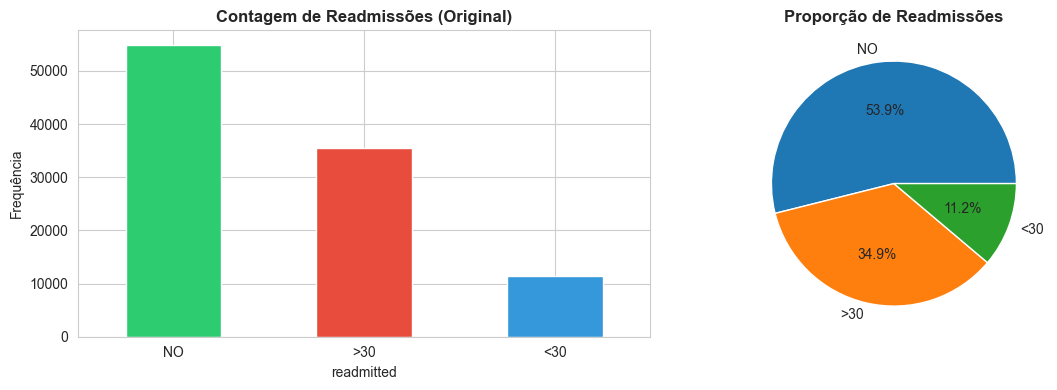


APÓS BINARIZAÇÃO
readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Desbalanceamento: 7.96:1


In [5]:
# Distribuição original de readmitted
print("\n" + "="*60)
print("DISTRIBUIÇÃO ORIGINAL DE READMITTED")
print("="*60)
target_counts = df['readmitted'].value_counts()
print(target_counts)
print(f"\nProporções:")
print(df['readmitted'].value_counts(normalize=True))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

target_counts.plot(kind='bar', ax=ax[0], color=['#2ecc71', '#e74c3c', '#3498db'])
ax[0].set_title('Contagem de Readmissões (Original)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Frequência')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

(df['readmitted'].value_counts(normalize=True) * 100).plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Proporção de Readmissões', fontsize=12, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Binarização
print(f"\n" + "="*60)
print("APÓS BINARIZAÇÃO")
print("="*60)
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted_binary'].value_counts())
print(f"\nDesbalanceamento: {(df['readmitted_binary']==0).sum()/(df['readmitted_binary']==1).sum():.2f}:1")

## 3. Análise de Variáveis Demográficas


DISTRIBUIÇÃO DE IDADE
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


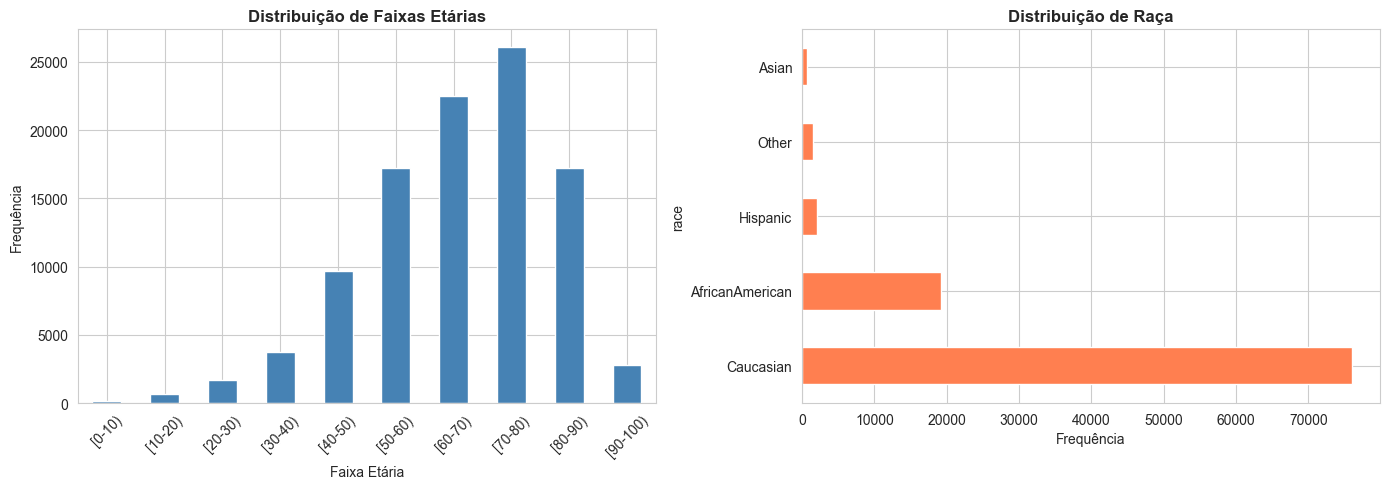


Gênero:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [6]:
# Distribuição etária
print("\n" + "="*60)
print("DISTRIBUIÇÃO DE IDADE")
print("="*60)
print(df['age'].value_counts().sort_index())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df['age'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Distribuição de Faixas Etárias', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Faixa Etária')
ax[0].set_ylabel('Frequência')
ax[0].tick_params(axis='x', rotation=45)

df['race'].value_counts().plot(kind='barh', ax=ax[1], color='coral')
ax[1].set_title('Distribuição de Raça', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Frequência')

plt.tight_layout()
plt.show()

# Gênero
print(f"\nGênero:")
print(df['gender'].value_counts())

## 4. Análise de Diagnósticos (ICD-9)

In [7]:
print("\n" + "="*60)
print("DIAGNÓSTICOS ICD-9")
print("="*60)

for i in [1, 2, 3]:
    col = f'diag_{i}'
    print(f"\n{col}: {df[col].nunique()} valores únicos")
    print(f"  Exemplos: {df[col].unique()[:10]}")
    print(f"  Valores faltantes: {df[col].isna().sum()} ({100*df[col].isna().sum()/len(df):.2f}%)")


DIAGNÓSTICOS ICD-9

diag_1: 716 valores únicos
  Exemplos: ['250.83' '276' '648' '8' '197' '414' '428' '398' '434' '250.7']
  Valores faltantes: 21 (0.02%)

diag_2: 748 valores únicos
  Exemplos: [nan '250.01' '250' '250.43' '157' '411' '492' '427' '198' '403']
  Valores faltantes: 358 (0.35%)

diag_3: 789 valores únicos
  Exemplos: [nan '255' 'V27' '403' '250' 'V45' '38' '486' '996' '197']
  Valores faltantes: 1423 (1.40%)


## 5. Análise de Medicamentos


MEDICAMENTOS
Total de medicamentos: 23

Exemplo - Distribuição de 'metformin':
metformin
No        81778
Steady    18346
Up         1067
Down        575
Name: count, dtype: int64


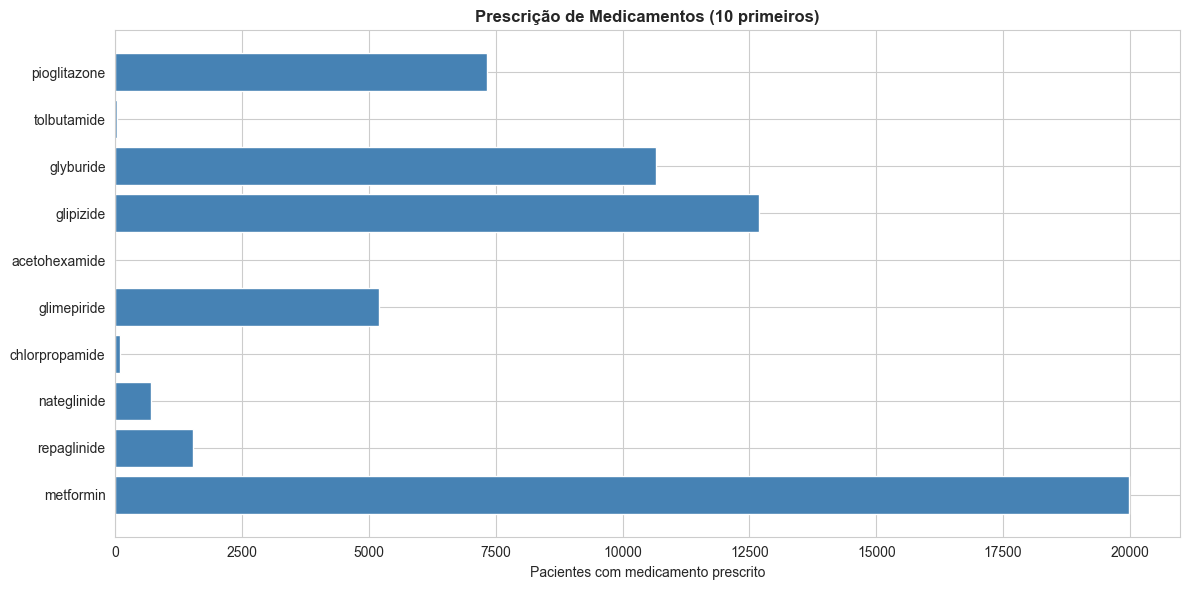

In [8]:
medicamentos = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

print("\n" + "="*60)
print("MEDICAMENTOS")
print("="*60)
print(f"Total de medicamentos: {len(medicamentos)}")

# Verificar valores únicos
print(f"\nExemplo - Distribuição de 'metformin':")
print(df['metformin'].value_counts())

# Visualizar padrão de medicamentos
fig, ax = plt.subplots(figsize=(12, 6))

meds_presentes = []
for med in medicamentos[:10]:  # Primeiros 10
    meds_presentes.append((df[med] != 'No').sum())

ax.barh(medicamentos[:10], meds_presentes, color='steelblue')
ax.set_xlabel('Pacientes com medicamento prescrito')
ax.set_title('Prescrição de Medicamentos (10 primeiros)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Valores Faltantes


VALORES FALTANTES
                              Coluna  Missing  Percentual
weight                        weight    98569   96.858479
max_glu_serum          max_glu_serum    96420   94.746772
A1Cresult                  A1Cresult    84748   83.277322
medical_specialty  medical_specialty    49949   49.082208
payer_code                payer_code    40256   39.557416
race                            race     2273    2.233555
diag_3                        diag_3     1423    1.398306
diag_2                        diag_2      358    0.351787
diag_1                        diag_1       21    0.020636


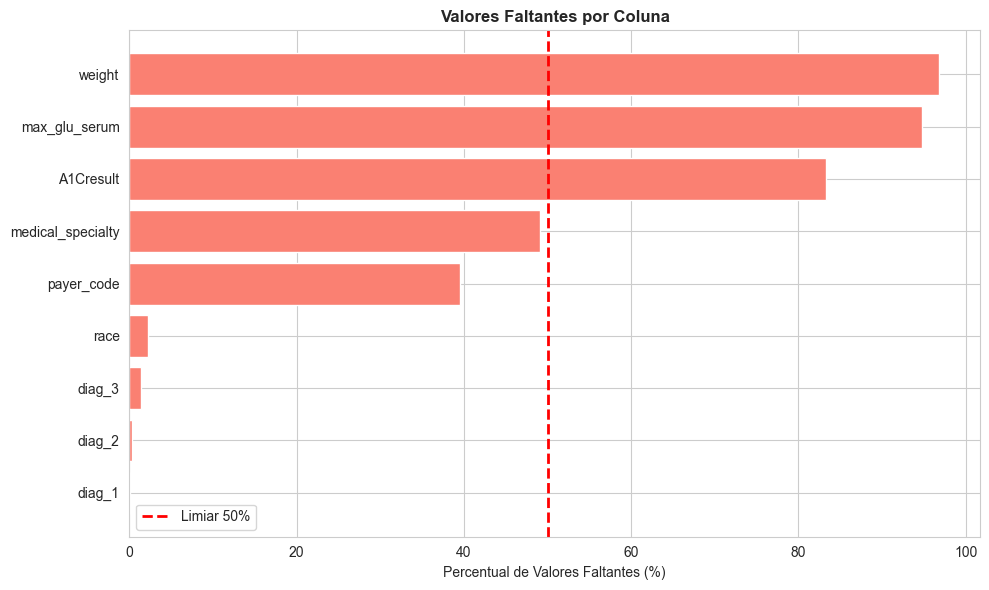

In [9]:
print("\n" + "="*60)
print("VALORES FALTANTES")
print("="*60)

missing = pd.DataFrame({
    'Coluna': df.columns,
    'Missing': df.isnull().sum(),
    'Percentual': (df.isnull().sum() / len(df) * 100)
}).sort_values('Percentual', ascending=False)

print(missing[missing['Missing'] > 0])

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
missing_cols = missing[missing['Missing'] > 0].sort_values('Percentual')
ax.barh(missing_cols['Coluna'], missing_cols['Percentual'], color='salmon')
ax.set_xlabel('Percentual de Valores Faltantes (%)')
ax.set_title('Valores Faltantes por Coluna', fontsize=12, fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='Limiar 50%')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Análise de Numeração de Procedimentos


PROCEDIMENTOS E MEDICAMENTOS
       time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count     101766.000000       101766.000000   101766.000000    101766.000000   
mean           4.395987           43.095641        1.339730        16.021844   
std            2.985108           19.674362        1.705807         8.127566   
min            1.000000            1.000000        0.000000         1.000000   
25%            2.000000           31.000000        0.000000        10.000000   
50%            4.000000           44.000000        1.000000        15.000000   
75%            6.000000           57.000000        2.000000        20.000000   
max           14.000000          132.000000        6.000000        81.000000   

       number_outpatient  number_emergency  number_inpatient  number_diagnoses  
count      101766.000000     101766.000000     101766.000000     101766.000000  
mean            0.369357          0.197836          0.635566          7.422607  
std   

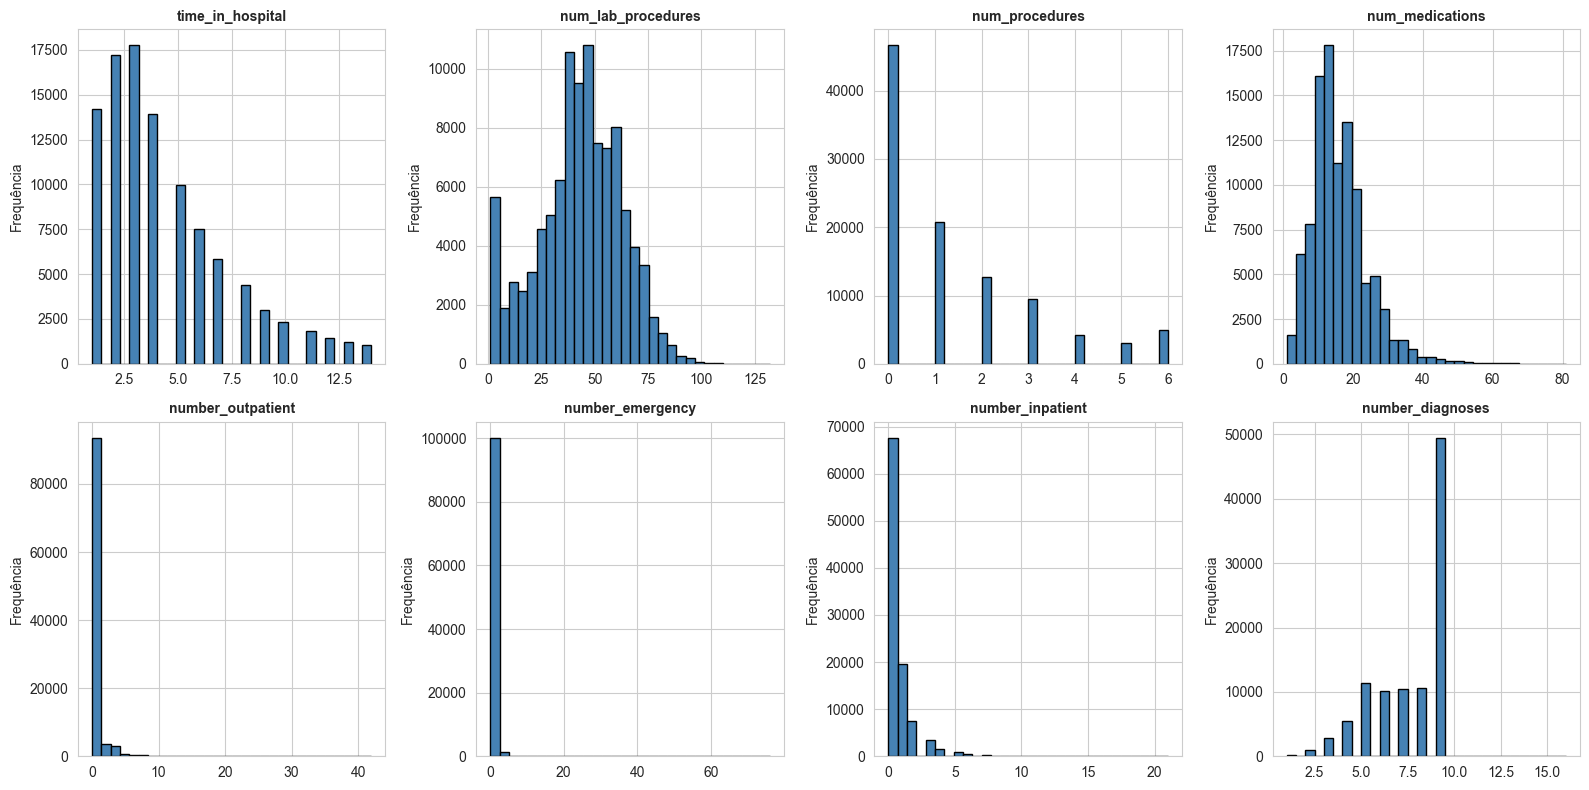

In [10]:
print("\n" + "="*60)
print("PROCEDIMENTOS E MEDICAMENTOS")
print("="*60)

procedimentos = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                 'num_medications', 'number_outpatient', 'number_emergency',
                 'number_inpatient', 'number_diagnoses']

print(df[procedimentos].describe())

fig, ax = plt.subplots(2, 4, figsize=(16, 8))
ax = ax.flatten()

for i, proc in enumerate(procedimentos):
    ax[i].hist(df[proc], bins=30, color='steelblue', edgecolor='black')
    ax[i].set_title(proc, fontsize=10, fontweight='bold')
    ax[i].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

## 8. Próximos Passos

Após essa exploração, o pipeline de pré-processamento executará:

1. ✓ Download automático
2. ✓ Substituição de `?` por NaN
3. Remoção de colunas com >50% missing
4. Filtragem de discharge_disposition_id
5. Deduplicação por paciente
6. Binarização de target
7. Codificação de idade
8. Categorização de ICD-9
9. Ordinal encoding de medicamentos
10. One-hot encoding de variáveis nominais
11. Normalização (dentro do Pipeline)

Após isso, executar o experimento fatorial com 15 combinações.